# Inferring magnet-NV geometry from 2D ODMR contour scans  
By: Addison NewRingeisen and Brandon Chyi

Package name and importing:

In [2]:
import nv

## Description of Generative Model
**An explanation of the NV resonance model, model parameters, and choice on priors**

We will model the observed data as an image of flouresence from a single NV center measured at a fixed microwave frequency $f_{MW}$. Each data point is recorded at a pixel in a 2D array, such that our data is:
$$
D = \{y_{ij}\}
$$
where $y_{ij}$ is the measured flourescene rate in kCounts/s at pixel $(i, j)$. The goal, from this data, is to infer the parameters of a magnetic dipole from this image. 

For the purpose of this preliminary model, we will only consider the following parameters: 
- single magnetic dipole
- a known NV axis $\mathbf{\hat{n}}$
- Lorentzian fluorescence dip as a function of detuning
- constant background floresence, with independent Gaussian pixel noise

**Parameters:** For the full parameter vector, consider:

$$
\theta = \left(x_d, y_d, z_d, m_x, m_y, m_z, \beta_0, C, \Gamma, \sigma\right).
$$

Where:

- $(x_d, y_d, z_d)$: dipole position
- $(m_x, m_y, m_z)$: dipole moment components
- $\beta_0$: background offset
- $C$: fluorescence dip contrast
- $\Gamma$: resonance linewidth parameter
- $\sigma$: standard deviation of the pixel noise

What we will have as input from the image data is the pixel coordinate, i.e. the relative position of the NV center with respect to the NV center. For the defined coordinates $(i, j)$, the full scan coordiante is then
$$
\mathbf{r_{ij}} = (x_{ij}, y_{ij}, z_{NV})
$$
Where $z_{NV}$ is the height of the imaging plane. 

**Dipole B-Field**: For the sake of model explanation, consider the simplest case of a magnetic field. We model the magnet as a simple point dipole located at 
$$
\mathbf{r_d} = (x_d, y_d, z_d)
$$
with dipole moment

$$
\mathbf{m} = (m_x, m_y, m_z)
$$
This allows us to define
$$
\mathbf R_{ij} = \mathbf r_{ij} - \mathbf r_d,
\qquad
R_{ij} = \|\mathbf R_{ij}\|,
\qquad
\hat{\mathbf R}_{ij} = \frac{\mathbf R_{ij}}{R_{ij}}.
$$
As the parameter for distance and direction of the displacement of the NV from the dipole. Then, we know that for any given pixel $(i, j)$, the dipole field at that pixel is: 
$$
\mathbf B_{ij}(\theta) = \frac{\mu_0}{4\pi R_{ij}^3} \left[3(\mathbf m \cdot \hat{\mathbf R}_{ij}) \hat{\mathbf R}_{ij} - \mathbf m \right].
$$
Finally, if we assume that the NV orientation is known, then the relevant field component which will impact the spin transition of the NV center is: 
$$
B_{\parallel,ij}(\theta) = \mathbf B_{ij}(\theta) \cdot \hat{\mathbf n}.
$$
i.e. we only care about the component of the field is that is parallel to the NV center axis. 

**Resonance model:** Throughout the duration of the scan, we are sending in a known, fixed microwave freqeuncy to the system. What we then care about is the detuning between this microwave field and where the NV spin transition resonance is. We apply a known fixed microwave frequency $f_{mw}$ to the NV center. The resonance condition is determined by the detuning between this drive frequency and the local NV transition frequency, which depends on the magnetic field projected along the NV axis. When the magnetic field pushes the NV spin transition into resonance with the applied mw field, we see a dip in its output flouresence, which forms the basis of the relevant contour scans. The spin transition frequency may be modeled as:
$$
f_{NV, ij}(\theta) = D \pm \gamma B_{\parallel ,ij}(\theta)
$$
Where D is the zero field splitting and $\gamma$ is the known NV gyromagnetic factor. The detuning from resonance is thus:
$$
\Delta_{ij}(\theta) = f_{MW} - f_{NV,ij} = f_{MW} - (D \pm \gamma B_{\parallel ,ij}(\theta))
$$

and resonance occurs when $\Delta_{ij}(\theta) \approx 0$, i.e when the local projected magnetic field shifts the NV transition into resonance with the applied microwave tone. 

The dip itself then can be modeled using a Lorentzian line shape. There will be some global background florecense, as well as a contrast parameter $C$ which is intrinsic to the NV center, and will be known. Typically, $C$ is in the range of 15 - 30%. Let us then define our signal as: 
$$
\mu_{ij}(\theta) = \beta_0\left[1 - C \frac{1}{1 + \left( \frac{\Delta_{ij}(\theta)}{\Gamma} \right)^2} \right]
$$
Which means the flourecence will be lowest when $\Delta_{ij}$ is appraoching zero, which will produce the dark line that we see on the contour!

**Likelyhood:** Now for the likelyhood, we model each observed pixel as independent gaussian random variables:
$$
y_{ij} \mid \theta \sim \mathcal N\!\left(\mu_{ij}(\theta), \sigma^2\right).
$$
such that the likelyhood for the entire image is
$$
p(D \mid \theta) = \prod_{i,j} \mathcal{N} \!\left(y_{ij} \mid \mu_{ij}(\theta), \sigma^2\right).
$$
Importantly, we are allowed to say use this model over the true counting statistics, given the range of counts we are receiving. Data is gathered at each pixel for 0.002 seconds, and we gather in the range of ~100 kCts/sec. This means for each pixel, we have received on the order of ~hundreds of photons, allowing us to establish the likelyhood as an independent gaussian. 

**Priors:** Now, in order to complete our model, we need to assign priors to each of the unknown parameters. 

For the dipole position, we say that the dipole may appear anywhere within the region of the image with equal probability: 
$$
x_d \sim \mathrm{Uniform}(x_{\min}, x_{\max}),
\qquad
y_d \sim \mathrm{Uniform}(y_{\min}, y_{\max}),
\qquad
z_d \sim \mathrm{Uniform}(z_{\min}, z_{\max}).
$$

For the dipole itself, it is typically magnetized experimentally by applying an external field approximately along the z-axis. Thus, we should use a prior that favors a dipole moment that points roughly along the z-axis, but allows for imperfect alignment in x and y. We define a vector $\mathbf{\hat{m}}$ with components: 
$$
m_x \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_y \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_z \sim \mathcal{N}(m_{z,0}, s_z^2)
$$
Keep in mind, this component of the model remains elusive, and its definition will change based on the type of data that we want to infer. Further explanations will occur in the notebook.

For the magnitude of the magnetic dipole, we say:
$$
\log m_{\mathrm{mag}} \sim \mathcal N(\log m_0,\sigma_m^2),
\qquad
m_{\mathrm{mag}} = e^{\log m_{\mathrm{mag}}},
$$
Using the log form to account for the fact that the magnetic moment is extremely small. To help with divergences, we deal with the log form first, and then convert it later, so that we can finally pull out the full dipole info:
$$
\mathbf m = m_{\mathrm{mag}} \hat{\mathbf m}.
$$
The expected mean value of the dipole magnitude is something that may be determed experimentally, considering the magnetic remanence and volume of your magnet.  

For the background, the baseline intensity has a rough expected scale, which can be determined emperically from the images or prior scans with the NV center. For this reason, we center the prior at this value with a normal distribution:
$$
\beta_0 \sim \mathcal{N}(\bar{y}, s_{\beta_0}^2)
$$

For the parameters linewidth and noise standard deviation, we know we need to enforce positivity when we have a generally known scale for the parameter. For this case, we use exponential parameters: 
$$
\Gamma \sim \text{Exponential}(\lambda_\Gamma), 
\qquad
\sigma \sim \text{Exponential}(\lambda_\sigma), 
$$

As well as the contrast $C$ for the system, which we know is a value bounded by $[0, 1]$. By looking at ESR scans prior to the collection of image data, we have a very good idea of what this value should be. With this information we utilize a Beta prior:
$$
C \sim \text{Beta}(\alpha_C, \beta_C)
$$

Now we may finally think about the joint distribution, which may be written as: 
$$
p(\theta, D) = p(\theta)\prod_{i,j} p(y_{ij}\mid \theta)
$$

with

$$
p(\theta) =
p(x_d)p(y_d)p(z_d)p(m_x)p(m_y)p(m_z)
p(\beta_0)p(C)p(\Gamma)p(\sigma),
$$

and 

$$
p(y_{ij}\mid \theta) = \mathcal N\!\left(y_{ij}\mid \mu_{ij}(\theta), \sigma^2\right)
$$

So that the posterior distribution is:

$$
p(\theta \mid D)
\propto
p(D\mid \theta)\,p(\theta).
$$

## Simulate data and infer using generative model

**Use simulated data for proof of concept and model checking**

We aim to recreate data as seen in the image here, collected for real in the lab. This says that a constant mw tone of 2.77 GHz was sent into the system, and the scan is between 30 and 50 volts in the X and Y directions. In this case, we have a known volt-to-um cnversion rate of 0.02, which allows us to relate the image to physical space. 

<img src="Screenshot 2026-05-03 at 4.25.16 PM.png" alt="drawing" width="400"/>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# ---------------------------------------
# Define some set parameters for the scan
# ---------------------------------------

n_pix = 45
vx = np.linspace(30.0, 50.0, n_pix)
vy = np.linspace(30.0, 50.0, n_pix)

VX, VY = np.meshgrid(vx, vy)

# ---------------------------------------
# We have a known volt -> um conversion
# ---------------------------------------
volt_to_m = 0.02e-6
X = VX * volt_to_m
Y = VY * volt_to_m

# ---------------------------------------
# Our third dimension will be the image data
# ---------------------------------------
Z = np.zeros_like(X)

Now we define our diple field to output the magnetic field vector components at a given distance, as well as the implementation of the flourecence model defined above: 

In [4]:
MU0 = 1.25663706127e-6 # N/A^2 = T m / A
MU0_OVER_4PI = MU0 / (4 * np.pi)

def dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec):
    """
    Will compute the magnetic field from a dipole
    on a 2D grid

    Input
    -----
    X, Y, Z: 2D arrays representing the observation coordinates
    x_d, y_d, z_d: float: dipole position
    m_vec : array of length 3: dipole moment vector

    Returns
    -------
    Bx, By, Bz : 2D arrays, magnetic field components
    
    """
    mx, my, mz = m_vec

    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R = np.sqrt(R2)

    # include a safety cutoff value to top R^3, R^5 terms from blowing up
    lim = 1e-30
    R = np.maximum(R, lim)

    m_dot_R = mx*Rx + my*Ry + mz*Rz

    Bx = MU0_OVER_4PI * (3.0 * m_dot_R * Rx / R**5 - mx / R**3)
    By = MU0_OVER_4PI * (3.0 * m_dot_R * Ry / R**5 - my / R**3)
    Bz = MU0_OVER_4PI * (3.0 * m_dot_R * Rz / R**5 - mz / R**3)

    return Bx, By, Bz # will now be in Tesla

In [5]:
GAMMA_NV_MHZ_PER_T = 28024.95138616912 # MHz/T
D_NV_MHZ = 2870.0 # MHz

def mean_fluorescence_dipole(
    X, Y, Z, 
    x_d, y_d, z_d, 
    m_vec, 
    n_vec, 
    beta0, 
    C, 
    Gamma, 
    f_mw,
    branch_sign=-1
):
    """
    Computes the noiseless fluorescence image for a fixed microwave tone.

    Input
    ----------
    X, Y, Z : 2D ndarray
        Observation coordinates of the scan grid, in METERS

    x_d, y_d, z_d : float
        Cartesian coordinates of the dipole position, in METERS.

    m_vec : array of shape (3,)
        Dipole moment vector [m_x, m_y, m_z], in A m^2.

    n_vec : array-like of shape (3,)
        Unit vector giving the NV orientation axis.

    beta0 : float
        Background fluorescence level, in kc/s.

    C : float
        ODMR contrast parameter. Dimensionless, between 0, 1

    Gamma : float
        Lorentzian linewidth parameter, in MHz.

    f_mw : float
        Applied microwave frequency, in MHz.

    branch_sign : int, optional
        Chooses which ODMR branch is being driven.
        Use -1 for the lower-frequency branch and +1 for the upper-frequency
        branch.

    Returns
    -------
    mu : 2D ndarray
        Data for fluorescence image, in kc/s.

    B_par : 2D ndarray
        Magnetic field component projected along the NV axis, in TESLA.

    Delta : 2D ndarray
        Frequency detuning f_mw - f_nv at each pixel, in MHz.
    """

    Bx, By, Bz = dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec)

    nx, ny, nz = n_vec
    B_par = nx*Bx + ny*By + nz*Bz

    f_nv = D_NV_MHZ + branch_sign * GAMMA_NV_MHZ_PER_T * B_par
    Delta = f_mw - f_nv

    lorentzian = 1.0 / (1.0 + (Delta/Gamma)**2)
    mu = beta0 * (1.0 - C*lorentzian)

    return mu, B_par, Delta

Now we begin the simulation of the data:

In [8]:
# ---------------------------------------
# Choose the TRUE parameter values
# ---------------------------------------

UM = 1e-6
# dipole position, arbitrary position
x_d_true = 0.80 * UM
y_d_true = 0.81 * UM
z_d_true = -0.078 * UM

# Dipole moment (mostly z with small tilt)
m_dir = np.array([0.15, -0.08, 1.00])
m_dir = m_dir / np.linalg.norm(m_dir)

m_mag_true = 3e-16 # A m^2 
m_vec_true = m_mag_true*m_dir
# Our known NV axis
n_vec_true = np.array([0.0, 0.0, 1.00])

# Global Background
beta0_true = 145.0 #kc/s

# Lorentzian dip params
C_true = 0.30
Gamma_true = 40.0 # same freq units as delta

# known mw input tone
f_mw_true = 2770.0 # MHz

# Which ODMR branch are we driving?
branch_sign_true = -1 # we almost always drive lower branch

# Noise level?
sigma_true = 2.5 #kc/s

In [9]:
# ---------------------------------------------
# Simulate the noiseless image from true values
# ---------------------------------------------

mu_true, Bpar_true, Delta_true = mean_fluorescence_dipole(
    X, Y, Z,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

# And now draw noisy observations
rng = np.random.default_rng(1)
y_sim = rng.normal(loc=mu_true, scale=sigma_true, size=mu_true.shape)

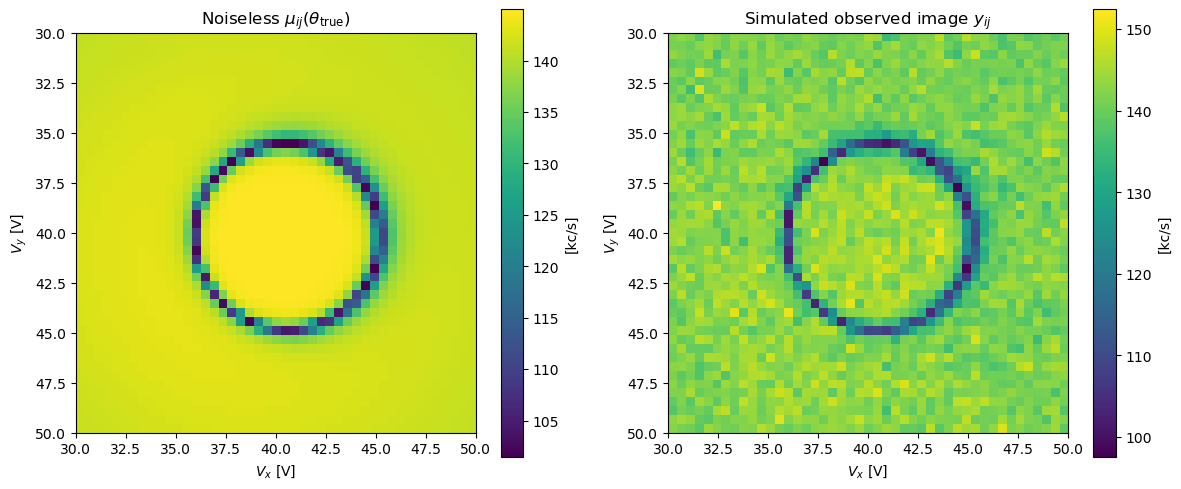

In [10]:
# -----------------------
# Plot our simulated data
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(mu_true,extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[0].set_title("Noiseless $\\mu_{ij}(\\theta_{\\rm true})$")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")
plt.colorbar(im0, ax=axes[0], label="[kc/s]")

im1 = axes[1].imshow(y_sim, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[1].set_title("Simulated observed image $y_{ij}$")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")
plt.colorbar(im1, ax=axes[1], label="[kc/s]")

plt.tight_layout()
plt.show()

Which shows that our model is able to replicate data that looks like the real image data!

### Inferring parameters from simulated data

In [11]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

C:\Users\Brandon\miniforge3\envs\phys201\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Lets start by make our functions pytensor compatible so we can use them with PyMC:

In [12]:
MU0 = 1.25663706127e-6 # T m / A
MU0_OVER_4PI = MU0 / (4.0 * np.pi) # ~1e-7 T m / A

def dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z):
    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R2 = pt.maximum(R2, 1e-30)
    R = pt.sqrt(R2)

    m_dot_R = m_x * Rx + m_y * Ry + m_z * Rz

    Bx = MU0_OVER_4PI * (3.0 * m_dot_R * Rx / R**5 - m_x / R**3)
    By = MU0_OVER_4PI * (3.0 * m_dot_R * Ry / R**5 - m_y / R**3)
    Bz = MU0_OVER_4PI * (3.0 * m_dot_R * Rz / R**5 - m_z / R**3)

    return Bx, By, Bz

In [13]:
D_NV_MHZ = 2870.0 # zero-field splitting [MHz]
GAMMA_NV_MHZ_PER_T = 28024.951386 # NV gyromagnetic ratio [MHz/T]

def mean_fluorescence_dipole_pt(X, Y, Z, x_d, y_d, z_d,
                         m_x, m_y, m_z,
                         beta0, C, Gamma, f_mw, n_vec,
                        branch_sign=-1):
    
    Bx, By, Bz = dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z)

    nx, ny, nz = n_vec
    B_par = nx * Bx + ny * By + nz * Bz

    f_nv = D_NV_MHZ + branch_sign * GAMMA_NV_MHZ_PER_T * B_par
    Delta = f_mw - f_nv
    
    L = 1.0 / (1.0 + (Delta / Gamma)**2)
    mu = beta0 * (1.0 - C * L)

    return mu, B_par, Delta

We now implement the model using our priors. For now, we assume that the dipol magnitude and direction are known. 

In [21]:
with pm.Model() as nv_dipole_model:

    X_data = pm.Data("X_data", X.astype("float64"))
    Y_data = pm.Data("Y_data", Y.astype("float64"))

    Z_data = pm.Data("Z_data", Z.astype("float64"))

    y_out = pm.Data("y_sim", y_sim.astype("float64"))

    # Giving the model something easy to work with initially...
    z_d_um = pm.TruncatedNormal("z_d_um", mu=0.078, sigma=0.05, lower=0, upper=0.1)
    x_d_um = pm.Uniform("x_d_um", lower=0.55, upper=1.05)
    y_d_um = pm.Uniform("y_d_um", lower=0.55, upper=1.05)
    
    phi = pm.VonMises("phi", kappa = 10)
    mz = pm.Deterministic("mz", np.cos(phi))
    theta = pm.Uniform("theta", lower = 0, upper = 2*np.pi)
    mx = pm.Deterministic("mx", np.cos(theta)*np.sin(phi))
    my = pm.Deterministic("my", np.sin(theta)*np.sin(phi))

    m_mag = pm.Uniform("m_mag", lower = 1e-16, upper=1e-15)
    # and converting to um for physical meaning
    z_d = -z_d_um * 1e-6
    x_d = x_d_um * 1e-6
    y_d = y_d_um * 1e-6

    # Take average count from data set as guess
    beta0 = pm.Normal("beta0", mu=float(np.mean(y_sim)), sigma=10.0)

    # From 0-1, average of 0.3, weighted towards lower values
    C = pm.Beta("C", alpha=2.0, beta=5.0)

    # Relatively well known parameter from prior ESR scans
    Gamma = pm.Exponential("Gamma", lam=1/40.0)

    # implement the model using the known dipole parameters
    mu_model, B_par, Delta = mean_fluorescence_dipole_pt(
        X_data, Y_data, Z_data,
        x_d, y_d, z_d,
        m_mag*mx, m_mag*my, m_mag*mz,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    pm.Normal("y_like", mu=mu_model, sigma=sigma_true, observed=y_out)

In [ ]:
with nv_dipole_model:
    nv_dipole_samples = pm.sample(
        tune=3000,
        draws=5000,
        chains=6,
        init="adapt_diag",
        target_accept=0.9,
    )

C:\Users\Brandon\miniforge3\envs\phys201\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using adapt_diag...
Multiprocess sampling (6 chains in 4 jobs)
NUTS: [z_d_um, x_d_um, y_d_um, phi, theta, m_mag, beta0, C, Gamma]


Output()

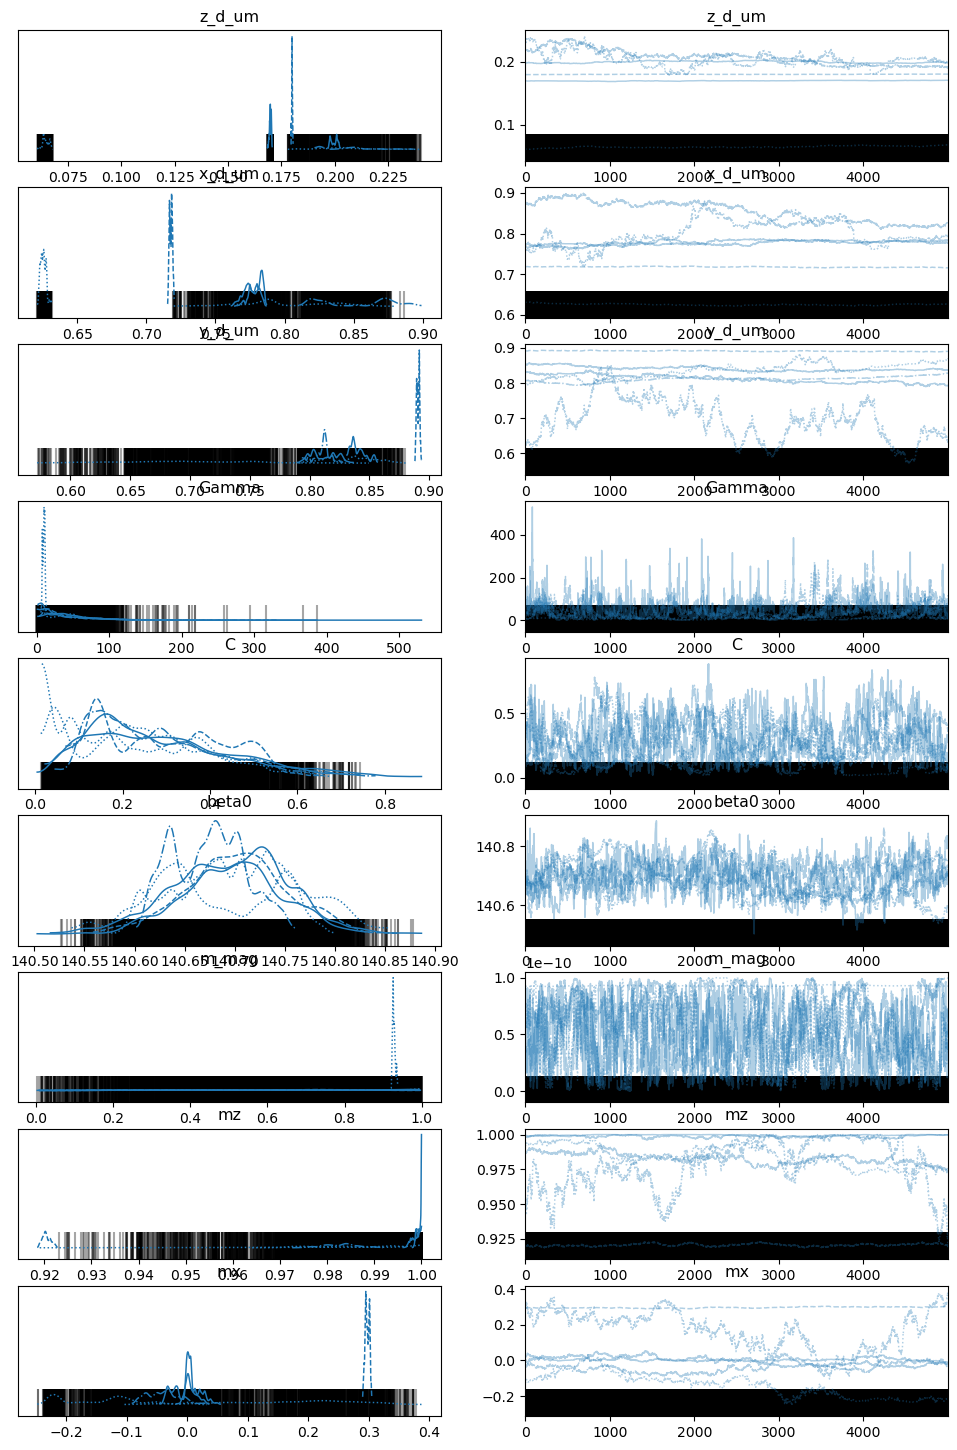

array([[<Axes: ylabel='z_d_um'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='x_d_um'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='y_d_um'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='Gamma'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='C'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='z_d_um', ylabel='beta0'>, <Axes: xlabel='x_d_um'>,
        <Axes: xlabel='y_d_um'>, <Axes: xlabel='Gamma'>,
        <Axes: xlabel='C'>, <Axes: xlabel='beta0'>]], dtype=object)

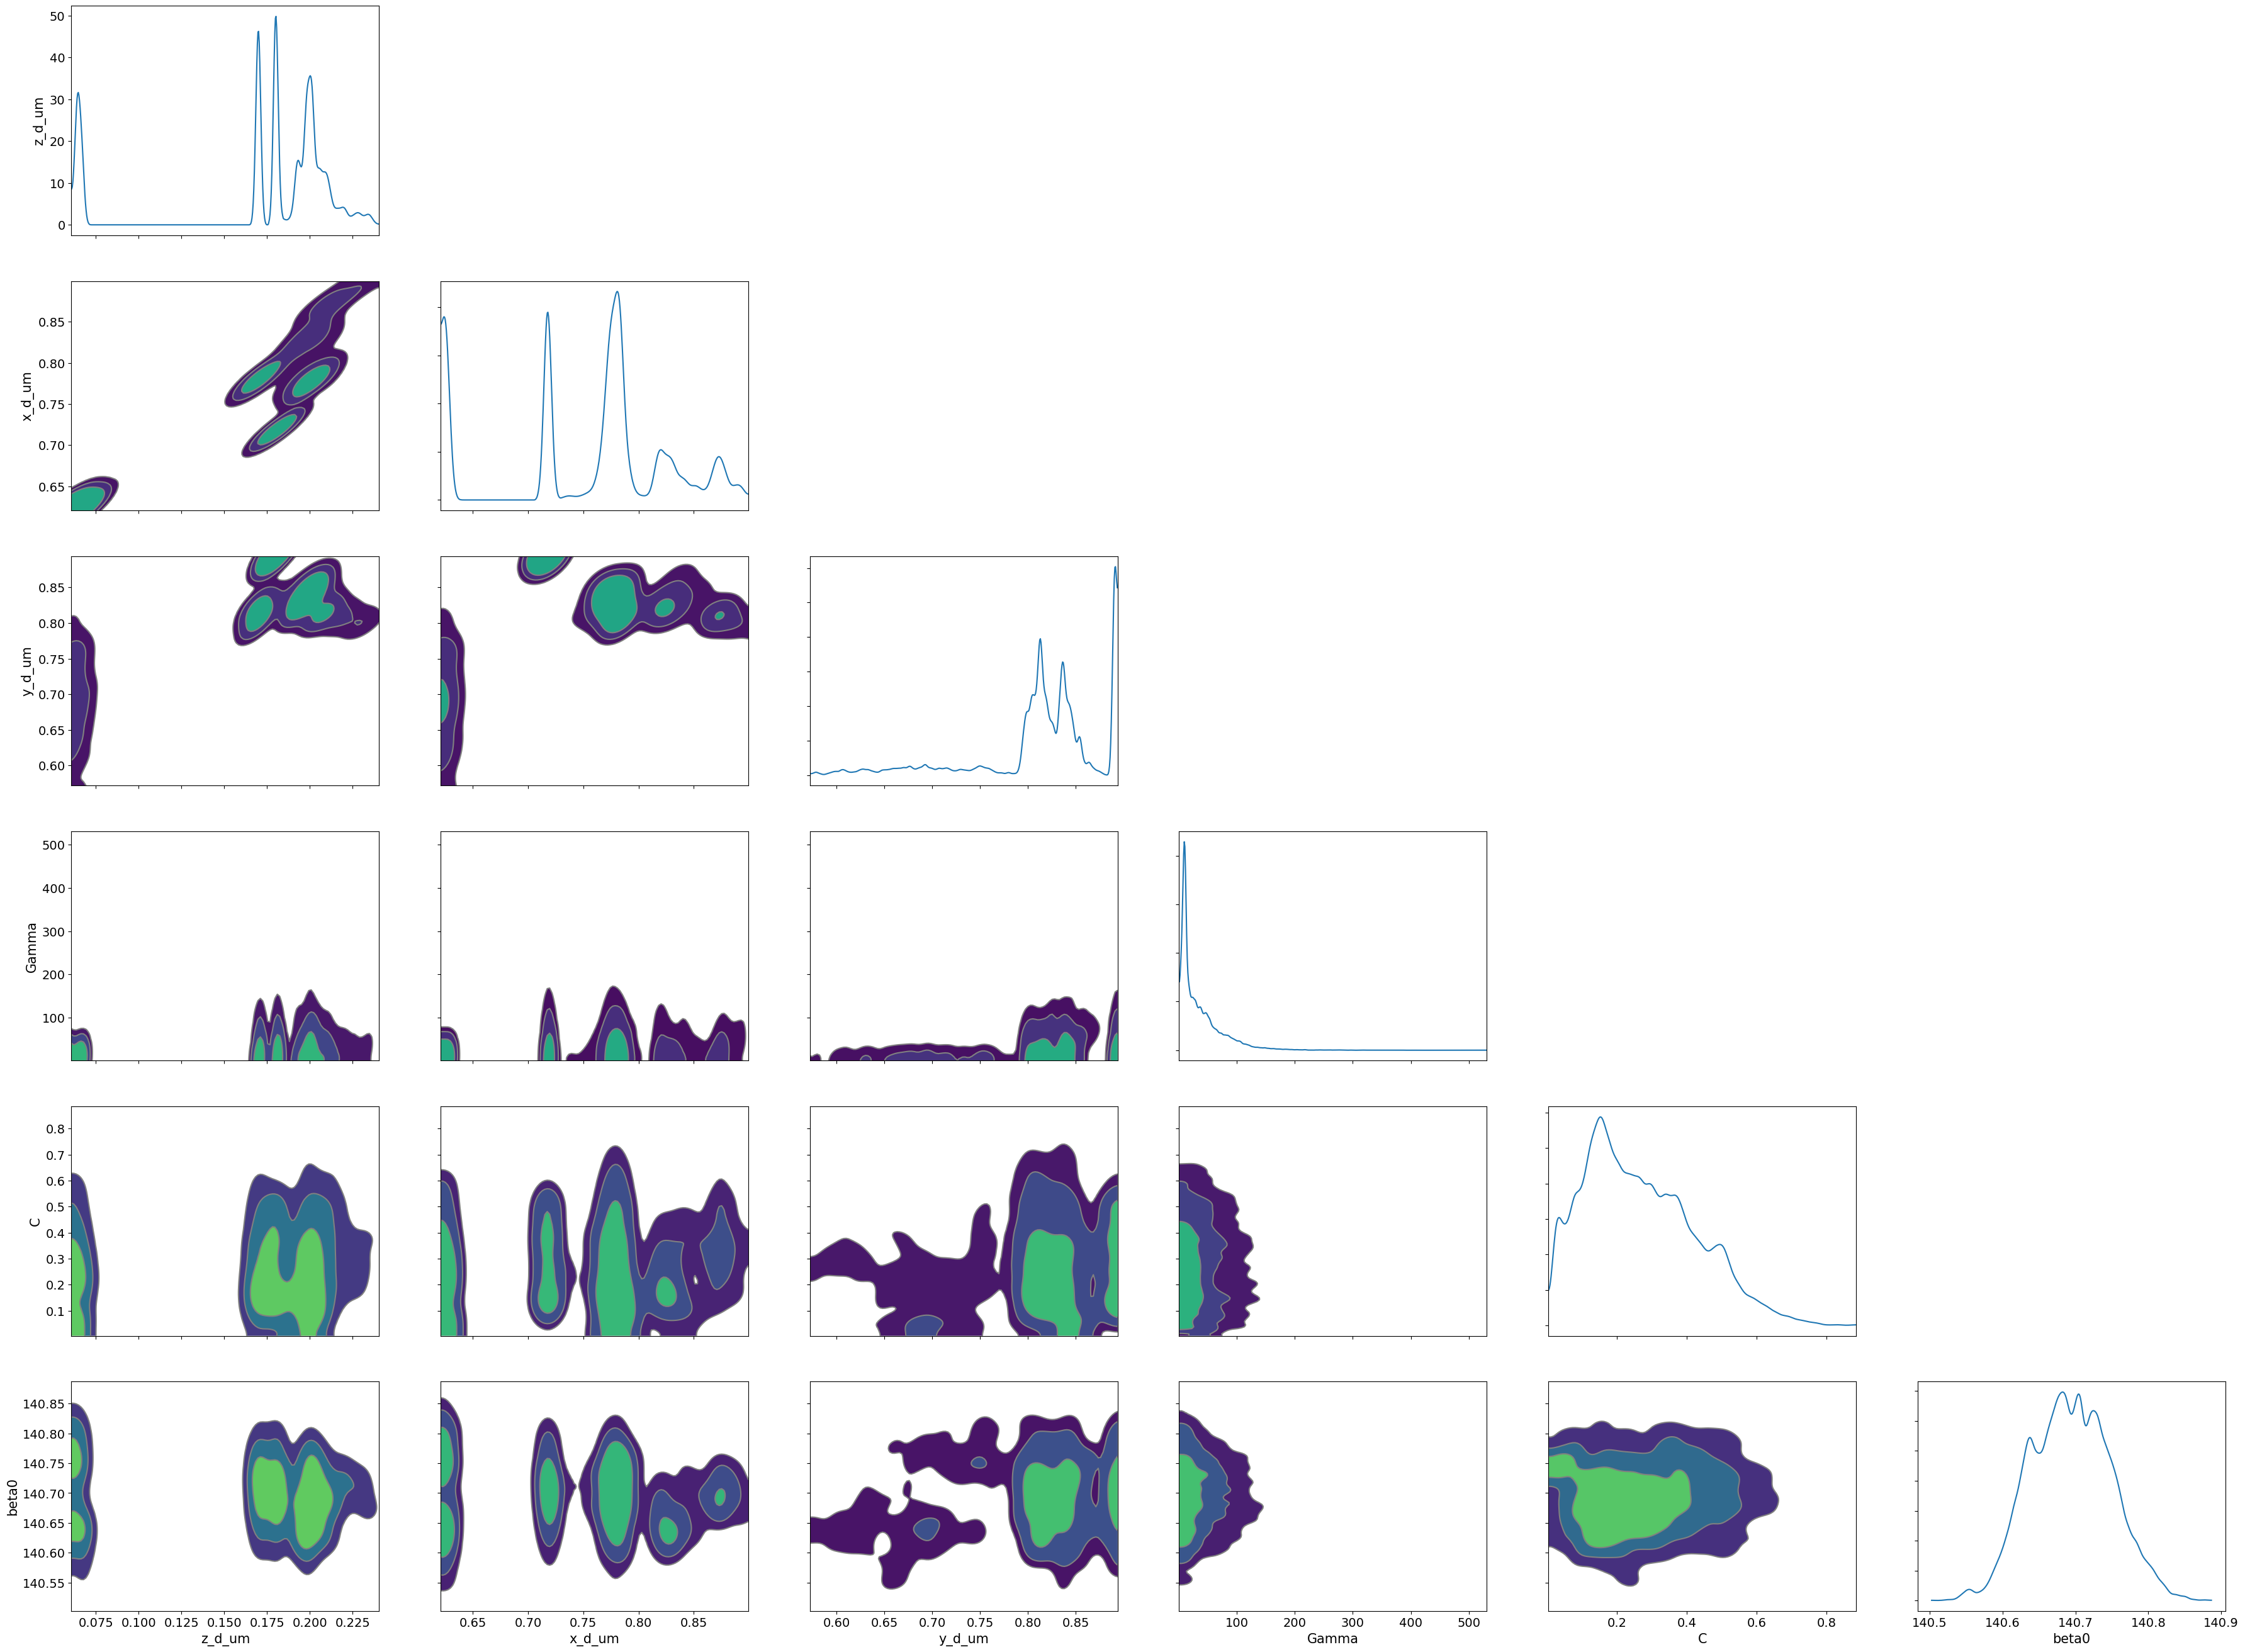

In [20]:
az.plot_trace(nv_dipole_samples, var_names=["z_d_um",  "x_d_um", "y_d_um", "Gamma", "C", "beta0","m_mag", "mz","mx"])
plt.show()

az.summary(nv_dipole_samples, var_names=["z_d_um",  "x_d_um", "y_d_um", "Gamma", "C", "beta0"])

az.plot_pair(
    nv_dipole_samples,
    var_names=["z_d_um",  "x_d_um", "y_d_um", "Gamma", "C", "beta0"],
    kind="kde",
    marginals=True
)

We see that we are able to reproduce the true parameters of the distribution!  
**NOTE:** At this point and with this model, letting the dipole be a free parameter may break your model! The system becomes unconstrained, eg small tilts in the dipole could compeltely change the x or y interpretation. Continue reading to see how to deal with this occurance. 

We may test our model against the orginal data: 

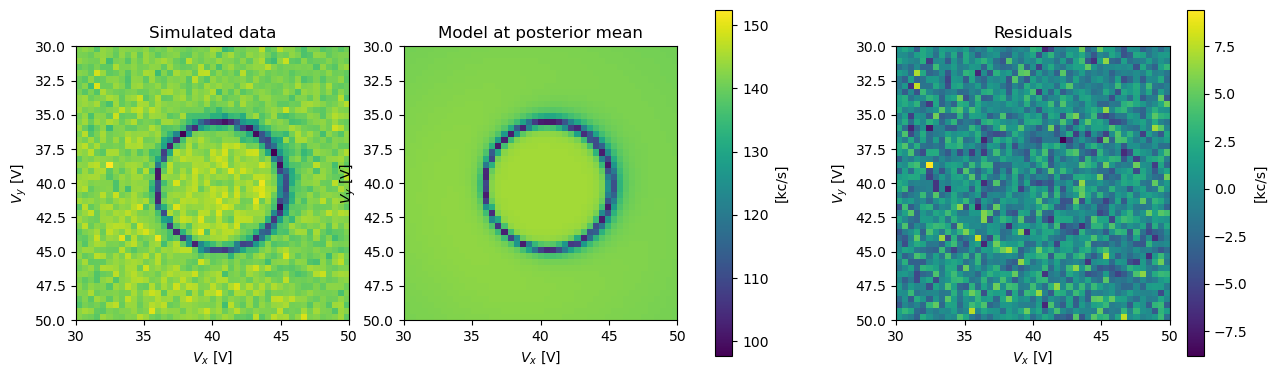

In [23]:
summary = az.summary(nv_dipole_samples, var_names=["x_d_um", "y_d_um", "z_d_um", "C", "beta0", "Gamma"])

x_mean = summary.loc["x_d_um", "mean"]
y_mean = summary.loc["y_d_um", "mean"]
z_mean = summary.loc["z_d_um", "mean"]
C_mean = summary.loc["C", "mean"]
beta0_mean = summary.loc["beta0", "mean"]
Gamma_mean = summary.loc["Gamma", "mean"]

x_fit = x_mean * 1e-6
y_fit = y_mean * 1e-6
z_fit = -z_mean * 1e-6

mu_fit, _, _ = mean_fluorescence_dipole(
    X, Y, Z,
    x_fit, y_fit, z_fit,
    m_vec_true,
    n_vec_true,
    beta0_mean, C_mean, Gamma_mean, f_mw_true,
    branch_sign=branch_sign_true
)

# Residuals
residual = y_sim - mu_fit

# Match color scales for viewing purppose
vmin = min(y_sim.min(), mu_fit.min())
vmax = max(y_sim.max(), mu_fit.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(
    y_sim,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[0].set_title("Simulated data")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")

im1 = axes[1].imshow(
    mu_fit,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Model at posterior mean")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")

im2 = axes[2].imshow(
    residual,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
)
axes[2].set_title("Residuals")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")

plt.colorbar(im0, ax=axes[:2], label="[kc/s]")
plt.colorbar(im2, ax=axes[2], label="[kc/s]")

plt.show()

We see that the residual just goes to noise! We have predicted our simulated data perfectly. 

At this point, we can visualize the model structure:

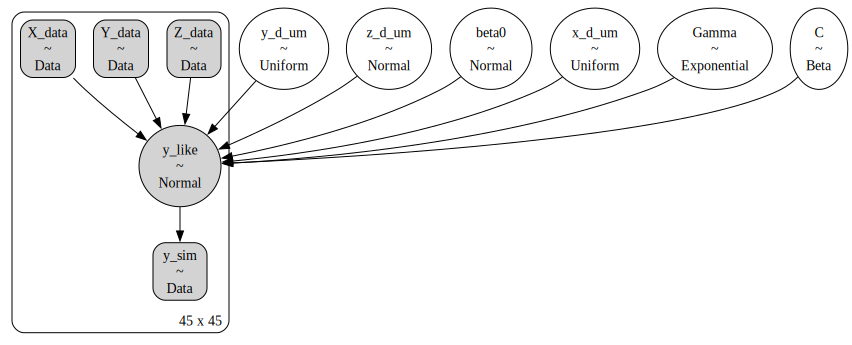

In [41]:
nv_dipole_model.to_graphviz()

## Accounting for unknown or imperfect dipole

For the dipole itself, in our lab it is typically magnetized experimentally by applying an external field along the z-axis. Thus, we should use a prior that favors a dipole moment that points roughly along the z-axis, but allows for imperfect alignment in x and y. As discussed in the previosu section, this turned out to be a rather challenging task. If we allow the vector to vary in all three dimensions, like this:
$$
m_x \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_y \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_z \sim \mathcal{N}(m_{z,0}, s_z^2)
$$
the problem becomes very unconstrained. Allowing the dipole direction to vary arbitrarily introduces strong degeneracies with the dipole depth and magnitude. We then thought about using a Von Mises prior on the dipole, to solve for the spherical coordinates in a parameterized approach. However, it quickly became apparent that this approach also diverges. This is likely because when the azimuthal angle is close to zero for a dipole expected to be oriented in $+z$, there forms a symmetry in which any angle of $\theta$ represents a nearly identical solution. This essentially creates a flat prior with no information, or a free variable, and the solver had a very difficult time handling it.  

So, we instead try to solve exclusively for small variations around a dipole in $+z$. To do this, Let $\mathbf m_{\mathrm{guess}}$ denote our initial guess for the dipole direction. We normalize it to obtain
$$
\hat{\mathbf u}_0 = \frac{\mathbf m_{\mathrm{guess}}}{\|\mathbf m_{\mathrm{guess}}\|}
$$
We then construct two unit vectors $\hat{\mathbf e}_1$ and $\hat{\mathbf e}_2$ such that
$$
\hat{\mathbf e}_1 \perp \hat{\mathbf u}_0, \qquad
\hat{\mathbf e}_2 \perp \hat{\mathbf u}_0, \qquad
\hat{\mathbf e}_1 \perp \hat{\mathbf e}_2.
$$
Thus, $\{\hat{\mathbf u}_0,\hat{\mathbf e}_1,\hat{\mathbf e}_2\}$ forms an orthonormal basis, with $\hat{\mathbf e}_1$ and $\hat{\mathbf e}_2$ spanning the tangent plane to the unit sphere at $\hat{\mathbf u}_0$.  

We can then use two local coordinates $\alpha_1$ and $\alpha_2$:
$$
\mathbf v = \hat{\mathbf u}_0 + \alpha_1 \hat{\mathbf e}_1 + \alpha_2 \hat{\mathbf e}_2
$$
describe tilt within the local tangent plane. For these priors, we choose 
$$
\alpha_1 \sim \mathcal N(0,\sigma_\alpha^2), \qquad
\alpha_2 \sim \mathcal N(0,\sigma_\alpha^2),
$$
which shows that we are confident the variable is likely around zero, but gives it a chance to deviate at small angles. From this data, we can then back out the exact components of the mangetic dipole after the sampling is done. 

For the magnitude of the magnetic dipole, we say:
$$
\log m_{\mathrm{mag}} \sim \mathcal N(\log m_0,\sigma_m^2),
\qquad
m_{\mathrm{mag}} = e^{\log m_{\mathrm{mag}}},
$$
To account for the fact that the magnetic moment is extremely small. To help with divergences, we deal with the log form first, and then convert it later, so that we can finally pull out the full dipole info:
$$
\mathbf m = m_{\mathrm{mag}} \hat{\mathbf m}.
$$

### Introduce mulitiple z-dim slices

Secondarily, we must somehow isolate the degeneracy between the magnitude of the dipole and the distance away from the NV center. In order to do so, we introduce multiple slices of Z-height data, keeping all other parameters constant, to help the model isolate the effect due to height. Here is an example, using simulated data, for prediction of the dipole direction and magnitude using 3 Z-slices:

In [27]:
# ---------------------------------------
# Define some set parameters for the scan
# ---------------------------------------

n_pix = 45
vx = np.linspace(30.0, 50.0, n_pix)
vy = np.linspace(30.0, 50.0, n_pix)

VX, VY = np.meshgrid(vx, vy)

# ---------------------------------------
# We have a known volt -> um conversion
# ---------------------------------------
volt_to_m = 0.02e-6
X = VX * volt_to_m
Y = VY * volt_to_m

# ---------------------------------------
# Our third dimension will be the image data
# ---------------------------------------
delta_z_step = 0.03e-6   # 30 nm

Z1 = np.zeros_like(X)
Z2 = np.zeros_like(X) + delta_z_step
Z3 = np.zeros_like(X) + 2 * delta_z_step

In [28]:
# ---------------------------------------------
# Simulate the noiseless image from true values
# ---------------------------------------------

mu_true_1, Bpar_true_1, Delta_true_1 = mean_fluorescence_dipole(
    X, Y, Z1,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

mu_true_2, Bpar_true_2, Delta_true_2 = mean_fluorescence_dipole(
    X, Y, Z2,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

mu_true_3, Bpar_true_3, Delta_true_3 = mean_fluorescence_dipole(
    X, Y, Z3,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

# And now draw noisy observations
rng = np.random.default_rng(1)

y_sim_1 = rng.normal(loc=mu_true_1, scale=sigma_true, size=mu_true_1.shape)
y_sim_2 = rng.normal(loc=mu_true_2, scale=sigma_true, size=mu_true_2.shape)
y_sim_3 = rng.normal(loc=mu_true_3, scale=sigma_true, size=mu_true_3.shape)

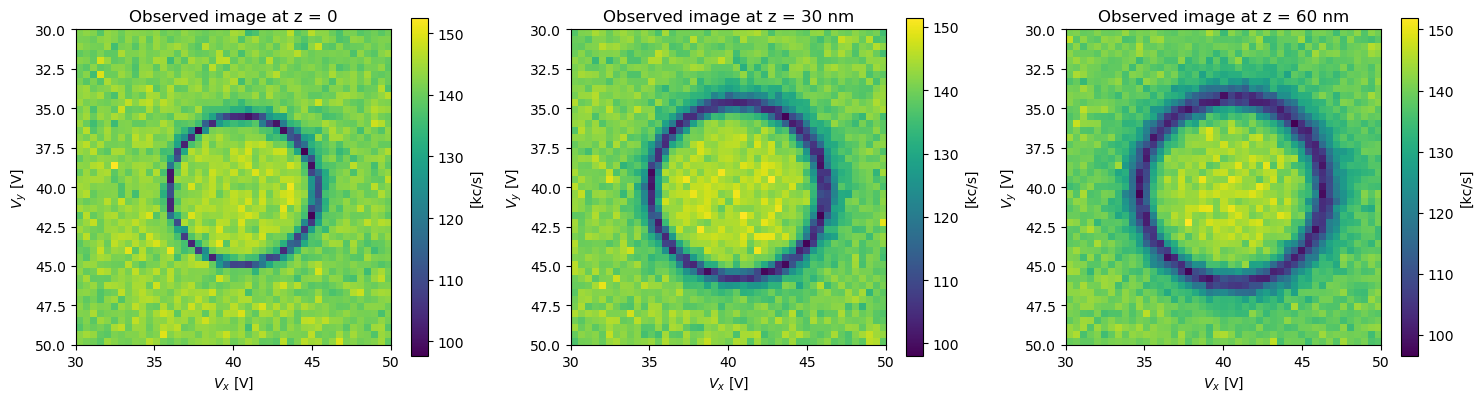

In [29]:
# -----------------------
# Plot our simulated data
# -----------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(y_sim_1, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[0].set_title("Observed image at z = 0")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")
plt.colorbar(im1, ax=axes[0], label="[kc/s]")

im2 = axes[1].imshow(y_sim_2, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[1].set_title(f"Observed image at z = 30 nm")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")
plt.colorbar(im2, ax=axes[1], label="[kc/s]")

im3 = axes[2].imshow(y_sim_3, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[2].set_title(f"Observed image at z = 60 nm")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")
plt.colorbar(im3, ax=axes[2], label="[kc/s]")

plt.tight_layout()
plt.show()

As expected, the contour expands as we get closer and closer to the dipole, keeping the resonant field constant. 

We now must create some helpers to implement the dipole direction method described above:

In [30]:
# Use grahm schmidt: use a starting vector t, then subtract off its projection in order 
# to get a vector perpendicular to your guess. Then, use the cross product to find a 
# second vector perpendicular to the first two. 
def make_local_basis(m_guess):
    u0 = np.asarray(m_guess, dtype=float)
    u0 = u0 / np.linalg.norm(u0)

    t = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(t, u0)) > 0.9:
        t = np.array([1.0, 0.0, 0.0])

    e1 = t - np.dot(t, u0) * u0
    e1 = e1 / np.linalg.norm(e1)

    e2 = np.cross(u0, e1)
    e2 = e2 / np.linalg.norm(e2)

    return u0, e1, e2

In [33]:
m_guess = np.array([0.0, 0.0, 1.0])
u0, e1, e2 = make_local_basis(m_guess)

with pm.Model() as nv_dipole_tilt_model:

    X_data = pm.Data("X_data", X.astype("float64"))
    Y_data = pm.Data("Y_data", Y.astype("float64"))

    Z1_data = pm.Data("Z1_data", Z1.astype("float64"))
    Z2_data = pm.Data("Z2_data", Z2.astype("float64"))
    Z3_data = pm.Data("Z3_data", Z3.astype("float64"))

    y1_sim = pm.Data("y1_sim", y_sim_1.astype("float64"))
    y2_sim = pm.Data("y2_sim", y_sim_2.astype("float64"))
    y3_sim = pm.Data("y3_sim", y_sim_3.astype("float64"))

    # geometry
    z_d_um = pm.Normal("z_d_um", mu=0.078, sigma=0.05)
    x_d_um = pm.Uniform("x_d_um", lower=0.55, upper=1.05)
    y_d_um = pm.Uniform("y_d_um", lower=0.55, upper=1.05)

    z_d = -z_d_um * 1e-6
    x_d = x_d_um * 1e-6
    y_d = y_d_um * 1e-6

    # dipole magnitude
    log_m_mag = pm.Normal("log_m_mag", mu=np.log(3e-16), sigma=0.5)
    m_mag = pt.exp(log_m_mag)

    # local coordinate system around guessed direction
    alpha1 = pm.Normal("alpha1", mu=0.0, sigma=0.03)
    alpha2 = pm.Normal("alpha2", mu=0.0, sigma=0.03)

    # we now have two linear parameters which describe variation around our guess
    vx = u0[0] + alpha1 * e1[0] + alpha2 * e2[0]
    vy = u0[1] + alpha1 * e1[1] + alpha2 * e2[1]
    vz = u0[2] + alpha1 * e1[2] + alpha2 * e2[2]

    norm = pt.sqrt(vx**2 + vy**2 + vz**2)

    mx_hat = vx / norm
    my_hat = vy / norm
    mz_hat = vz / norm

    m_x = m_mag * mx_hat
    m_y = m_mag * my_hat
    m_z = m_mag * mz_hat

    beta0 = pm.Normal("beta0", mu=float(np.mean([y_sim_1.mean(), y_sim_2.mean(), y_sim_3.mean()])), sigma=10.0)
    C = pm.Beta("C", alpha=2.0, beta=5.0)
    Gamma = pm.Exponential("Gamma", lam=1/40.0)

    mu_model_1, _, _ = mean_fluorescence_dipole_pt(
        X_data, Y_data, Z1_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    mu_model_2, _, _ = mean_fluorescence_dipole_pt(
        X_data, Y_data, Z2_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    mu_model_3, _, _ = mean_fluorescence_dipole_pt(
        X_data, Y_data, Z3_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    pm.Normal("y1_like", mu=mu_model_1, sigma=sigma_true, observed=y1_sim)
    pm.Normal("y2_like", mu=mu_model_2, sigma=sigma_true, observed=y2_sim)
    pm.Normal("y3_like", mu=mu_model_3, sigma=sigma_true, observed=y3_sim)

In [34]:
with nv_dipole_tilt_model:
    nv_samples = pm.sample(
        tune=2000,
        draws=2000,
        chains=4,
        init="adapt_diag",
        target_accept=0.95
    )

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [z_d_um, x_d_um, y_d_um, log_m_mag, alpha1, alpha2, beta0, C, Gamma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 83 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_d_um,0.078041,0.000081,0.077888,0.078193,0.000001,8.606509e-07,6040.458254,5329.643090,1.001213
x_d_um,0.800326,0.000334,0.799700,0.800945,0.000005,4.281893e-06,5160.769818,4927.613375,1.001342
y_d_um,0.810352,0.000340,0.809718,0.811002,0.000005,4.163160e-06,5045.980117,4954.441254,1.000215
log_m_mag,-35.740448,0.002024,-35.744332,-35.736787,0.000024,2.282451e-05,7321.118822,5696.998548,1.000077
alpha1,0.144575,0.004472,0.136358,0.153029,0.000062,5.624634e-05,5174.211970,4620.718546,1.001351
alpha2,-0.084904,0.004464,-0.093435,-0.076711,0.000063,5.494036e-05,5015.316790,4879.026050,1.000634
beta0,145.014815,0.060487,144.903945,145.130723,0.000739,6.600638e-04,6707.624316,5443.173701,1.001563
C,0.298349,0.001176,0.296135,0.300547,0.000013,1.264090e-05,7660.116630,6324.082890,1.000142
Gamma,40.347116,0.272386,39.859698,40.875722,0.003569,3.020335e-03,5814.015990,5412.894986,1.000392


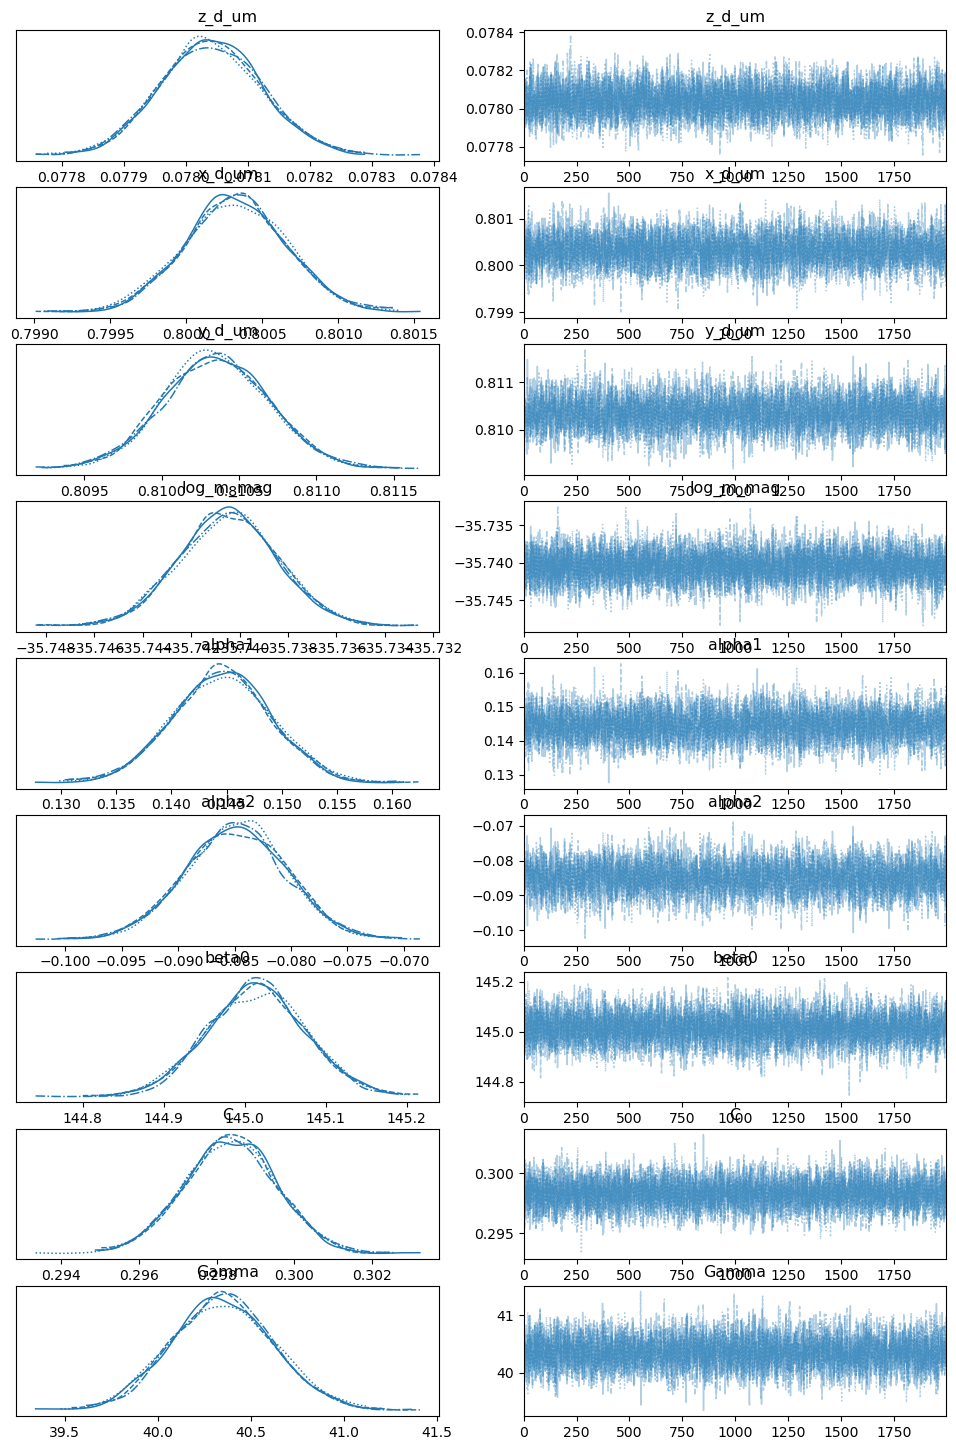

In [35]:
az.plot_trace(nv_samples,var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2", "beta0", "C", "Gamma"])

az.summary(nv_samples, var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2", "beta0", "C", "Gamma"], round_to=20)

And we may then recontruct our desired values from the model output: 

In [36]:
# now we can recontruct desired parameters from the sampled data

# Pull sampled variables from posterior
z_d_um_samples = nv_samples.posterior["z_d_um"].values.flatten()
x_d_um_samples = nv_samples.posterior["x_d_um"].values.flatten()
y_d_um_samples = nv_samples.posterior["y_d_um"].values.flatten()
log_m_mag_samples = nv_samples.posterior["log_m_mag"].values.flatten()
alpha1_samples = nv_samples.posterior["alpha1"].values.flatten()
alpha2_samples = nv_samples.posterior["alpha2"].values.flatten()

z_d_m_samples = z_d_um_samples * 1e-6
x_d_m_samples = x_d_um_samples * 1e-6
y_d_m_samples = y_d_um_samples * 1e-6

# Reconstruct dipole magnitude
m_mag_samples = np.exp(log_m_mag_samples)

# Reconstruct dipole direction unit vector from local basis
vx_samples = u0[0] + alpha1_samples * e1[0] + alpha2_samples * e2[0]
vy_samples = u0[1] + alpha1_samples * e1[1] + alpha2_samples * e2[1]
vz_samples = u0[2] + alpha1_samples * e1[2] + alpha2_samples * e2[2]

norm_samples = np.sqrt(vx_samples**2 + vy_samples**2 + vz_samples**2)

mx_hat_samples = vx_samples / norm_samples
my_hat_samples = vy_samples / norm_samples
mz_hat_samples = vz_samples / norm_samples

# Reconstruct full dipole moment components
m_x_samples = m_mag_samples * mx_hat_samples
m_y_samples = m_mag_samples * my_hat_samples
m_z_samples = m_mag_samples * mz_hat_samples

print("Posterior means:")
print("z_d_um =", z_d_um_samples.mean())
print("x_d_um =", x_d_um_samples.mean())
print("y_d_um =", y_d_um_samples.mean())
print("m_mag =", m_mag_samples.mean())
print("m_x =", m_x_samples.mean())
print("m_y =", m_y_samples.mean())
print("m_z =", m_z_samples.mean())

Posterior means:
z_d_um = 0.07804072865449709
x_d_um = 0.8003260157526828
y_d_um = 0.810352272475882
m_mag = 3.006917946239315e-16
m_x = 4.287252842178658e-17
m_y = -2.5177499210181778e-17
m_z = 2.965470173920049e-16


And visualize our dipole tilt from the point of view of the tangent plane to the 'guess' vector:

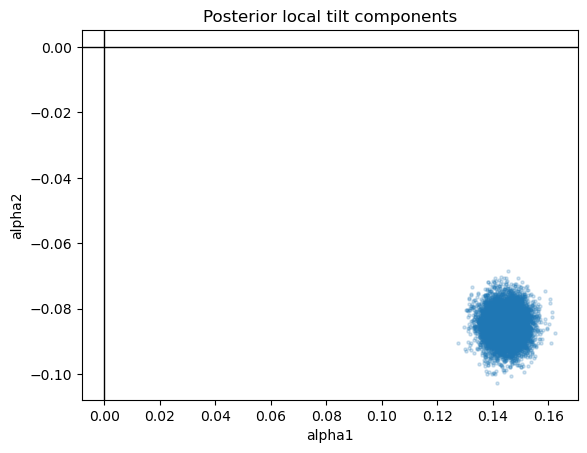

In [37]:
plt.scatter(alpha1_samples, alpha2_samples, s=5, alpha=0.2)
plt.axhline(0, color="k", lw=1)
plt.axvline(0, color="k", lw=1)
plt.xlabel("alpha1")
plt.ylabel("alpha2")
plt.title("Posterior local tilt components")
plt.show()

In [38]:
print("True dipole moment components:")
print(f"m_x_true = {m_vec_true[0]:.6e}")
print(f"m_y_true = {m_vec_true[1]:.6e}")
print(f"m_z_true = {m_vec_true[2]:.6e}")

print("\nPosterior mean dipole moment components:")
print(f"m_x_post = {m_x_samples.mean():.6e}")
print(f"m_y_post = {m_y_samples.mean():.6e}")
print(f"m_z_post = {m_z_samples.mean():.6e}")

True dipole moment components:
m_x_true = 4.436351e-17
m_y_true = -2.366054e-17
m_z_true = 2.957568e-16

Posterior mean dipole moment components:
m_x_post = 4.287253e-17
m_y_post = -2.517750e-17
m_z_post = 2.965470e-16


We see that with multiple sices and the dipole tilt model, we are able to reproduce parameters very close to the true tilt!

Importantly, and as a check, we see there is a strong correlation between alpha1 and x, and alpha2 and y. This confirms physically what we might assume, that tilting the dipole in one direction or another is very similar to shifting the whole dipole in a certain direction:

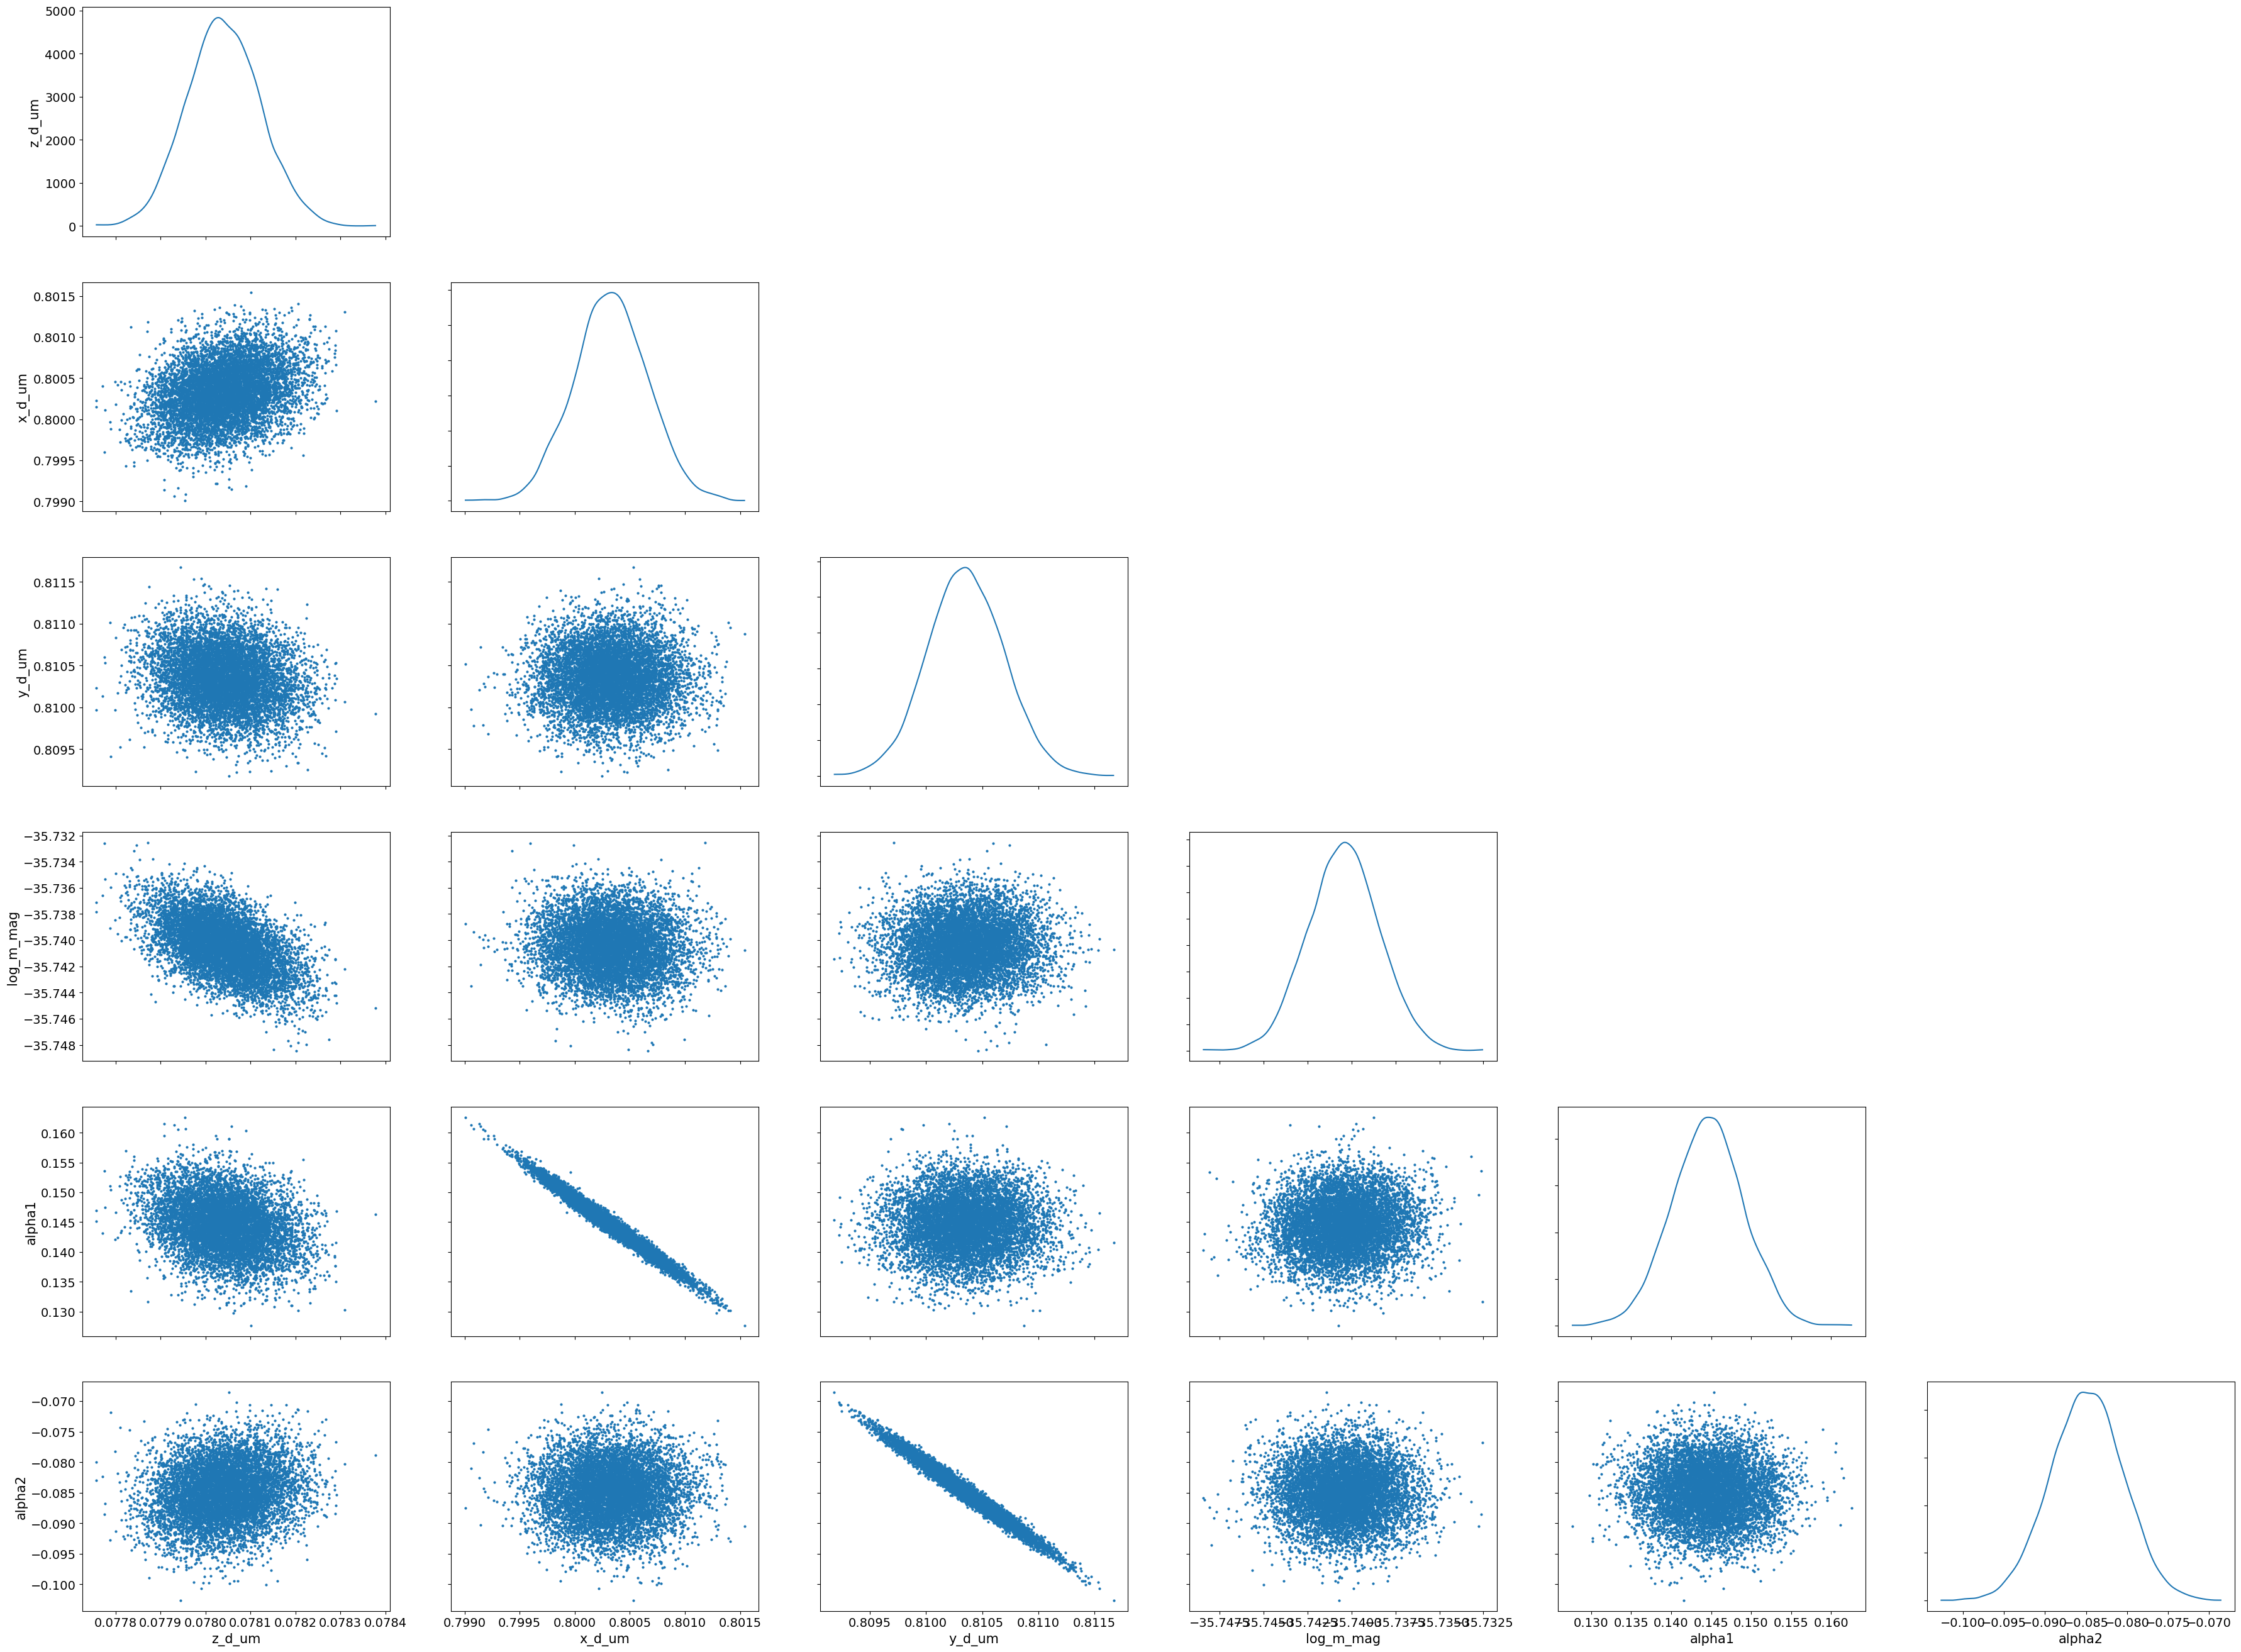

In [39]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2"],
    marginals=True
)
plt.show()

With these additions, the model structure now looks more complex, with multiple layers of data, 3 likelyhoods, and additional priors:

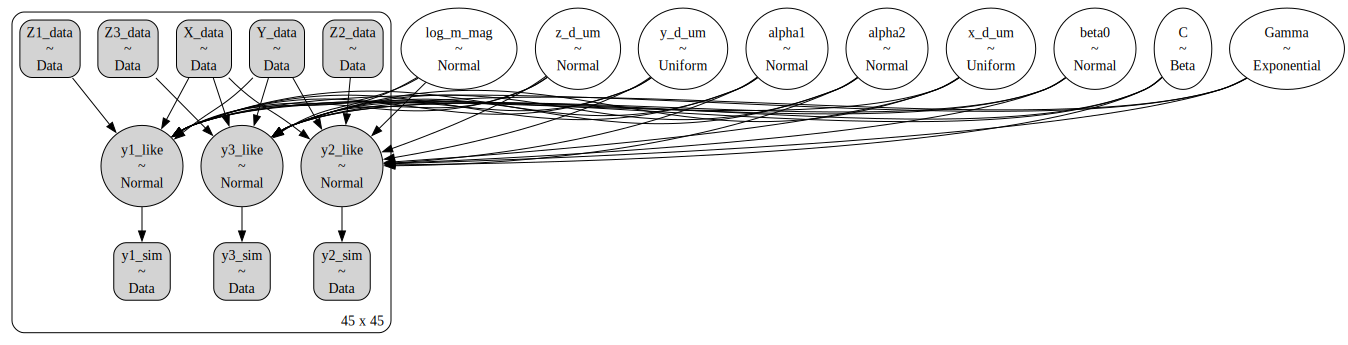

In [42]:
nv_dipole_tilt_model.to_graphviz()

# Testing with Real Data

**And how the model must adapt.**

**Symmetric, circular contours: utilize dipole approximation for larger distances**

**Testing NV orientation**

**Getting closer: increase model complexity**

**The rectangular prism model**

**What must be known, eg probably on some corner to generate enough XY gradient change to see a closed contour, setting up informed priors**

**Rectangular prism real data, intro of StudentT**